In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import copy

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()  #调用父类 nn.Module 的初始化函数
        self.fc = nn.Linear(28 * 28, 10)#数学原理：执行 y = xA^T + b

    def forward(self, x):#forward前向传播
        x = x.view(x.size(0), -1)  #把四维张量化为二维张量
        return self.fc(x)

#下载dataset数据库
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root='C:/Users/20550/data',
    train=True,  #True 表示加载训练集图片（给模型学习用）；如果设为 False，则加载 测试集图片（给模型考试用）
    download=True,  #如果指定的 root 路径里没有数据，程序会自动从互联网下载。如果已经下载过了，它会直接读取
    transform=transform #把每张图都变成张量
)

#把一个dataset数据库分解成num_clients个小数据库
num_clients = 2
data_per_client = len(dataset) // num_clients

client_datasets = [
    Subset(dataset, range(i * data_per_client, (i + 1) * data_per_client))#subset只记住了索引,为了少占内存
    for i in range(num_clients)
]  #列表推导式“给我创建一个列表，里面全是 Subset，至于 Subset 里的 i 是多少，请参考后面那个 for 循环。”

def local_train(model, dataloader, epochs=1):#epochs遍历数
    model.train() #开启训练模式
    criterion = nn.CrossEntropyLoss() #定义损失函数
    optimizer = optim.SGD(model.parameters(), lr=0.1) #定义优化器（lr是learning rate,即每次优化的步长）

    for _ in range(epochs):
        for data, target in dataloader:#“从数据加载器里一箱一箱地取货，每箱货里都有图片和标签，请分别把它们装进 data 和 target 这两个变量里。”
            optimizer.zero_grad() #清空梯度
            output = model(data) #前向传播。把图丢进模型，得到预测结果。即算出y以便求loss
            loss = criterion(output, target) #计算损失
            loss.backward() #反向传播 
            optimizer.step() #更新参数

    return model.state_dict() #这是一个 Python 字典，里面只存放模型训练后的权重（weights）和偏置（biases）

def fedavg(weights):#weights: 这是一个列表，里面装的是各个客户端发回来的 state_dict（也就是那些权重和偏置的字典）。
    avg_weights = copy.deepcopy(weights[0])#先copy第一个客户端的字典

    for key in avg_weights.keys(): 
        for i in range(1, len(weights)): #从第二个客户开始到最后一个
            avg_weights[key] += weights[i][key] #将后面客户端的权重/偏置相加
        avg_weights[key] /= len(weights) #得到平均权重/偏置

    return avg_weights #返回ave_weights字典，包含平均权重和平均偏置

global_model = SimpleNet() #定义全局模型为simplenet类（实例化）

client_loaders = [
    DataLoader(client_datasets[i], batch_size=64, shuffle=True)#local_train需要数据时64个图为一批，一批一批地传给它
    for i in range(num_clients)
]


In [11]:
# 1. 准备测试集
test_dataset = datasets.MNIST('C:/Users/20550/data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

def test(model, test_loader):
    # 1. 切换到评价模式（不更新权重，不使用 Dropout 等）
    model.eval()
    
    correct = 0
    total = 0
    
    # 2. 告诉 PyTorch：测试时不需要计算梯度（省内存，跑得快）
    with torch.no_grad():
        for data, target in test_loader:
            # 前向传播算得分 y
            output = model(data)
            
            # 找到得分最高的那个数字的索引
            # output.data 形状是 [64, 10]，1 代表在第 1 维度（10个得分）找最大
            _, predicted = torch.max(output.data, 1)
            
            # 统计总数和猜对的数量
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    print(f'测试集准确率: {accuracy:.2f}%')
    return accuracy

# 设定训练 5 轮
for r in range(5):
    print(f"\n--- 第 {r+1} 轮联邦学习开始 ---")
    local_weights = []
    
    # --- 阶段 A：每个客户端本地训练 ---
    for i in range(num_clients):
        # 必须 deepcopy，保证大家起点一致
        local_model = copy.deepcopy(global_model)
        
        # 本地训练，返回训练好的权重 w
        w = local_train(local_model, client_loaders[i])
        local_weights.append(w)
        print(f"客户端 {i} 训练完成")

    # --- 阶段 B：服务器聚合 ---
    global_weights = fedavg(local_weights)
    
    # --- 阶段 C：更新全局模型 ---
    global_model.load_state_dict(global_weights)

    # --- 阶段 D：【就在这里添加测试代码】 ---
    print(f"第 {r+1} 轮聚合完毕，正在测试全局模型...")
    test(global_model, test_loader)


--- 第 1 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 1 轮聚合完毕，正在测试全局模型...
测试集准确率: 89.87%

--- 第 2 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 2 轮聚合完毕，正在测试全局模型...
测试集准确率: 90.72%

--- 第 3 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 3 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.12%

--- 第 4 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 4 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.53%

--- 第 5 轮联邦学习开始 ---
客户端 0 训练完成
客户端 1 训练完成
第 5 轮聚合完毕，正在测试全局模型...
测试集准确率: 91.61%


In [12]:
#对抗样本：模型原本预测正确，你几乎不改图片模型，突然预测成另一个数字，而且很自信
global_model.eval()#测试模式

data, target = next(iter(test_loader))
data = data[:5]      # 取5张
target = target[:5]

output = global_model(data)
pred = output.argmax(dim=1)#在每一张图片的预测结果中，找出得分最高的那个类别的编号

print("真实标签:", target)#如果你在打印时不想看到 tensor(7)，而是只想看到干净的数字 7，你需要调用 .item() 方法.#item() 只能用于只包含一个元素的 Tensor
print("模型预测:", pred)

真实标签: tensor([7, 2, 1, 0, 4])
模型预测: tensor([7, 2, 1, 0, 4])


In [13]:
#方法一：自创for循环低效可运行代码
if data.grad is not None:
    data.grad.zero_()     # 清除输入数据的旧梯度
    
data.requires_grad = True
criterion = nn.CrossEntropyLoss()
adv_data=torch.empty(len(data), 1, 28, 28)
epsilon = 0.15 # 扰动强度，可调
output = global_model(data)
for i in range(len(data)):
    
    loss = criterion(output[i], target[i])
    loss.backward(retain_graph=True)#PyTorch 会沿着计算图反向推导，只计算「对 loss 有贡献的张量部分」的梯度
    #adv_data[i]= data[i] + epsilon * data.grad[i]
    adv_data[i] = data[i] + epsilon * data.grad[i].sign()#梯度的符号（data.grad.sign）代表了 “损失上升最快的方向”，只取方向（而非具体梯度值），能保证扰动是 “最有效” 的，且幅度可控。
    adv_data[i] = torch.clamp(adv_data[i], 0, 1)#图片的像素值被归一化到 [0,1] 区间


In [14]:
#方法二：正统代码
epsilon = 0.15 
# 1. 确保 data 开启梯度追踪
data.requires_grad = True

# 2. 一次性前向传播（得到整个 batch 的输出）
output = global_model(data)

# 3. 计算整个 batch 的损失
# 注意：这里不需要索引 [i]，直接传入整个 batch
criterion = nn.CrossEntropyLoss()
loss = criterion(output, target)

# 4. 反向传播（核心：一次性计算所有图片的独立梯度）
global_model.zero_grad() # 清除模型旧梯度
if data.grad is not None:
    data.grad.zero_()     # 清除输入数据的旧梯度
loss.backward()


data.grad = data.grad * 100


# 5. 利用梯度的符号生成对抗样本 (FGSM 公式)
# data.grad 此时已经是 (100, 1, 28, 28)，每一层对应一张图的独立梯度
#adv_data = data + epsilon * data.grad
adv_data = data + epsilon * data.grad.sign()

# 6. 限制数值范围在 [0, 1] 之间，防止像素溢出
adv_data = torch.clamp(adv_data, 0, 1)


In [16]:
# 方法三：和方法二很像但逻辑不完全一样（数学上一样）
data.requires_grad = True
criterion = nn.CrossEntropyLoss()
output = global_model(data)
loss = criterion(output, target)
if data.grad is not None:
    data.grad.zero_()     # 清除输入数据的旧梯度
loss.backward()#计算“数据梯度”以便下面生成对抗样本(训练时算的是模型的参数梯度，和此处不同)

epsilon =0.5 # 扰动强度，可调
#adv_data = data + epsilon * data.grad
adv_data = data - epsilon * data.grad.sign()#梯度的符号（data.grad.sign）代表了 “损失上升最快的方向”，只取方向（而非具体梯度值），能保证扰动是 “最有效” 的，且幅度可控。
adv_data = torch.clamp(adv_data, 0, 1)#图片的像素值被归一化到 [0,1] 区间

In [17]:
adv_output = global_model(adv_data)
adv_pred = adv_output.argmax(dim=1)

print("对抗样本预测:", adv_pred)
print("置信度:", torch.softmax(adv_output,dim=1)[0][adv_pred])

对抗样本预测: tensor([7, 2, 1, 0, 4])
置信度: tensor([1.0000e+00, 1.8319e-10, 7.0406e-13, 6.1043e-09, 1.9465e-09],
       grad_fn=<IndexBackward0>)


In [18]:
global_weights["fc.weight"].shape

torch.Size([10, 784])

In [19]:
global_weights['fc.bias'].shape

torch.Size([10])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

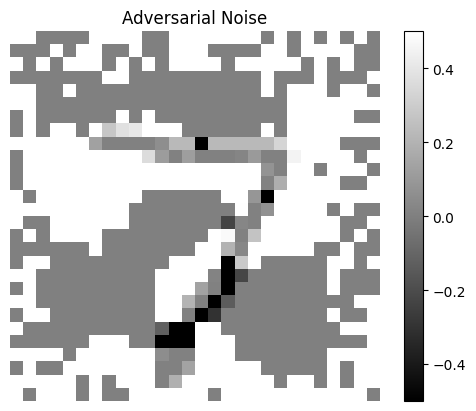

In [20]:
import matplotlib.pyplot as plt
noise = adv_data - data
noise = noise.detach()

plt.imshow(noise[0][0].cpu().numpy(), cmap='gray')
plt.colorbar()
plt.title("Adversarial Noise")
plt.axis('off')

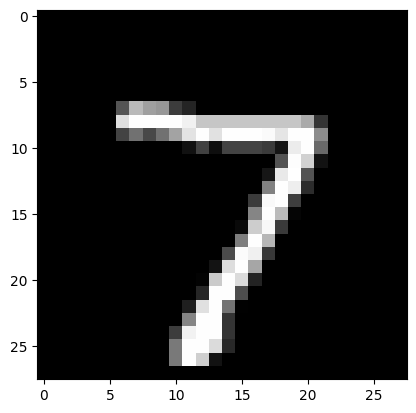

In [21]:
data = data.detach()
plt.imshow(data[0][0].cpu().numpy(), cmap='gray')

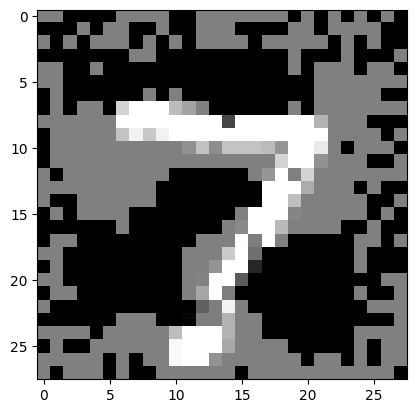

In [22]:
adv_data = adv_data.detach()
plt.imshow(adv_data[0][0].cpu().numpy(), cmap='gray')